In [3]:
%pip install psycopg2 sqlalchemy
%pip install pandas as pd
%pip install numpy as np
%pip install matplotlib.pyplot as plt
%pip install seaborn as sns

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.8 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 12.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


In [16]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [17]:
load_dotenv()  # Load environment variables from .env file

connection = psycopg2.connect(
    host=os.environ.get("DB_HOST", "localhost"),
    database=os.environ.get("DB_NAME", "postgres"),
    user=os.environ.get("DB_USER", "postgres"),
    password=os.environ.get("DB_PASSWORD"),
    port=os.environ.get("DB_PORT", "5432"),
)

In [18]:
query = "SELECT * FROM emailspam"
df = pd.read_sql_query(query, connection)

df

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_15716\295722241.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## Data Cleaning

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5572 non-null   object
 1   message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [21]:
df.isna().sum()

category    0
message     0
dtype: int64

In [26]:
df.duplicated().sum()

0

In [23]:
df.drop_duplicates(inplace=True)

## Explanatory Data Analysis

In [27]:
df

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [25]:
df.describe()

,category,message
count,5157,5157
unique,2,5157
top,ham,"Go until jurong point, crazy.. Available only ..."
freq,4516,1


<Axes: xlabel='category'>

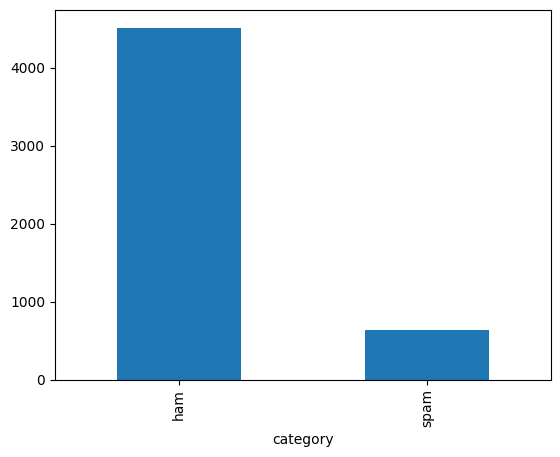

In [28]:
df['category'].value_counts().plot(kind='bar')

In [29]:
df['word_count'] = df['message'].apply(lambda x: len(str(x).split()))

In [31]:
df['char_count'] = df['message'].apply(lambda x: len(str(x)))

<Axes: title={'center': 'Word Count Distribution'}, ylabel='Frequency'>

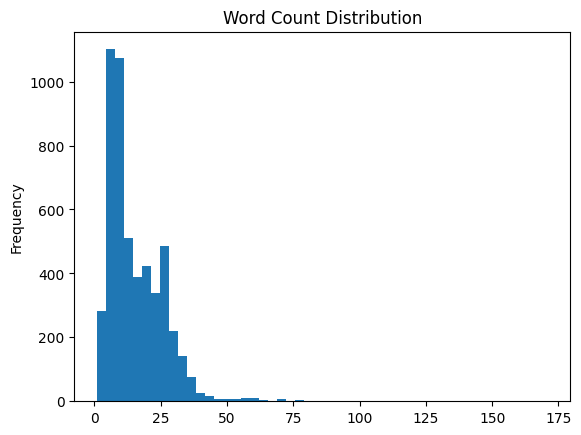

In [33]:
df['word_count'].plot(kind='hist', bins=50, title='Word Count Distribution')

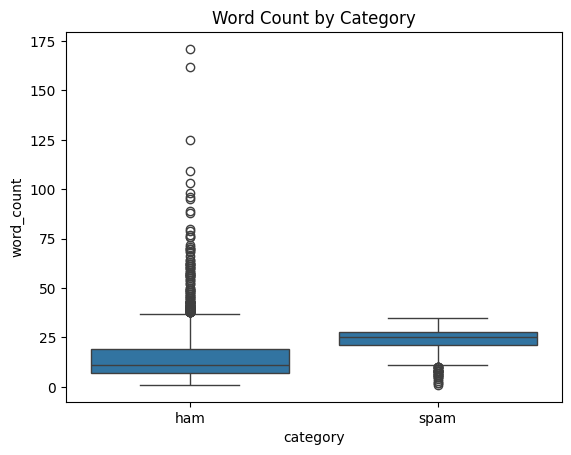

In [34]:
sns.boxplot(x='category', y='word_count', data=df)
plt.title('Word Count by Category')
plt.show()